# Modelo probabilístico de risco de óbito hospitalar

Este notebook aprofunda a análise de mortalidade da AV2 com um modelo probabilístico.
Em vez de só descrever as taxas de óbito, ajustamos uma **regressão logística** que
estima a probabilidade de uma internação terminar em óbito e mede **quanto cada fator
pesa** nesse risco.

**Pergunta que este modelo responde:**
> Mantendo os demais fatores fixos, quanto cada característica da internação (idade, sexo,
> COVID, uso de UTI, tempo de permanência) altera a chance de óbito hospitalar?

O objetivo não é prever o futuro, e sim **quantificar associações** de forma rigorosa,
usando odds ratios (razões de chance) e a curva ROC para medir a qualidade do modelo.

## 0. Configuração do ambiente

In [1]:
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import plotly.io as pio
pio.renderers.default = 'png'  # saídas estáticas, visíveis no GitHub

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import build_model as bm
print('Módulo do modelo carregado.')

Módulo do modelo carregado.


## 1. Fatores do modelo

Usamos cinco fatores disponíveis na silver, todos com leitura clínica direta:

| Fator | Como entra no modelo |
| ----- | -------------------- |
| Idade | em décadas de vida (odds ratio por +10 anos) |
| Sexo masculino | 1 = masculino, 0 = feminino |
| COVID | 1 = internação por COVID (CID B342) |
| Uso de UTI | 1 = teve ao menos um dia de UTI no mês |
| Permanência | dias internado (odds ratio por +1 dia) |

O alvo é `MORTE` (1 = óbito hospitalar). As variáveis contínuas são escaladas a uma
unidade interpretável para que o odds ratio tenha leitura imediata.

## 2. Treino do modelo

Ajustamos a regressão logística sobre a silver inteira, com separação treino/teste
(75%/25%, estratificada pelo óbito) para avaliar o modelo em dados que ele não viu.

In [2]:
resultado = bm.build_model(
    silver_path=ROOT / 'data' / 'silver' / 'sihsus_sp.parquet',
    gold_dir=ROOT / 'data' / 'gold',
    figuras_dir=ROOT / 'output' / 'figuras',
)
met = resultado['metricas'].iloc[0]
print(f"Treino: {int(met['n_treino']):,} internações | Teste: {int(met['n_teste']):,}")
print(f"AUC (teste):     {met['auc']:.3f}")
print(f"Acurácia (teste): {met['acuracia']:.3f}")

00:00:34 [INFO] Lendo silver: /Users/claudio/Code/me/school/data/project/sus-analytics/data/silver/sihsus_sp.parquet


00:00:34 [INFO] Registros: 9599861


00:00:37 [INFO] Treino: 7199895 | Teste: 2399966 | Óbitos no treino: 6.3%


00:00:42 [INFO] AUC = 0.847 | Acurácia = 0.938


00:00:42 [INFO] Tabelas do modelo salvas em /Users/claudio/Code/me/school/data/project/sus-analytics/data/gold


...

00:00:47 [INFO] Internação por COVID (vs outros)   OR = 2.62 (aumenta a chance de óbito)


00:00:47 [INFO] Idade (por década de vida)         OR = 1.60 (aumenta a chance de óbito)


00:00:47 [INFO] Sexo masculino (vs feminino)       OR = 1.20 (aumenta a chance de óbito)


00:00:47 [INFO] Permanência (por dia internado)    OR = 1.02 (aumenta a chance de óbito)


Treino: 7,199,895 internações | Teste: 2,399,966
AUC (teste):     0.847
Acurácia (teste): 0.938


## 3. Fatores associados ao óbito (odds ratios)

O odds ratio mede quanto cada fator multiplica a chance de óbito, mantendo os demais
fixos. Acima de 1, o fator **aumenta** o risco; abaixo de 1, reduz.

Fator,Odds ratio
Uso de UTI (vs sem UTI),5.15x
Internação por COVID (vs outros),2.62x
Idade (por década de vida),1.60x
Sexo masculino (vs feminino),1.20x
Permanência (por dia internado),1.02x


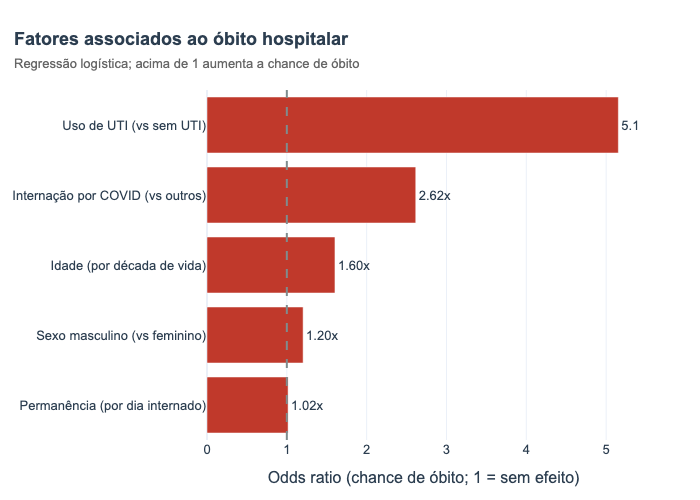

In [3]:
coef = resultado['coeficientes']
display(coef[['rotulo', 'odds_ratio']].rename(
    columns={'rotulo': 'Fator', 'odds_ratio': 'Odds ratio'}
).style.format({'Odds ratio': '{:.2f}x'}).hide(axis='index'))
bm.fig_odds(coef)

**Leitura.** Todos os fatores aumentam a chance de óbito, mas com pesos bem diferentes:

- **Uso de UTI (odds ratio ≈ 5,2):** é o fator mais forte. Uma internação que passou pela
  UTI tem cerca de **cinco vezes** mais chance de óbito que uma sem UTI, mantidos os demais
  fatores. Faz sentido: a UTI é, ela própria, marcador de gravidade.
- **COVID (≈ 2,6):** mesmo controlando por idade, sexo, UTI e permanência, a internação por
  COVID tem cerca de **2,6 vezes** mais chance de óbito que as demais. Ou seja, parte do
  excesso de mortalidade da COVID não se explica só por idade ou UTI: há um efeito próprio.
- **Idade (≈ 1,6 por década):** a cada 10 anos de vida, a chance de óbito cresce ~60%.
- **Sexo masculino (≈ 1,2):** homens têm ~20% mais chance de óbito que mulheres, coerente
  com o recorte demográfico da análise descritiva.
- **Permanência (≈ 1,02 por dia):** efeito pequeno por dia, mas que se acumula em
  internações longas.

## 4. Qualidade do modelo: curva ROC

A curva ROC mostra a capacidade do modelo de separar quem morre de quem recebe alta. A
área sob a curva (AUC) resume isso: 1,0 seria perfeito; 0,5 seria o acaso.

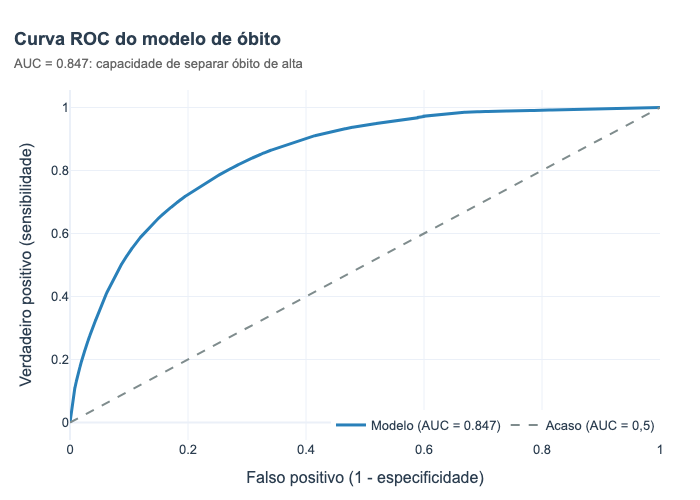

In [4]:
bm.fig_roc(resultado['fit'])

**Leitura.** O modelo alcança **AUC ≈ 0,85**, uma capacidade de discriminação
considerada boa: com cinco fatores simples e interpretáveis, ele separa bem os óbitos das
altas. A acurácia alta (~0,94) é esperada e deve ser lida com cautela, porque a base é
desbalanceada (a maioria das internações não termina em óbito); por isso a AUC é a métrica
mais informativa aqui.

## 5. Conclusão do modelo

O modelo confirma e **quantifica** o que a análise descritiva sugeriu:

- O **uso de UTI** e a **COVID** são os fatores que mais elevam o risco de óbito, mesmo
  controlando uns pelos outros.
- O **efeito próprio da COVID** (odds ratio ~2,6) reforça que a doença é mais letal não
  apenas por atingir idosos ou exigir UTI, mas por si mesma.
- O risco cresce de forma consistente com a **idade** e é maior em **homens**.

**Limitações.** A regressão logística captura associações, não causalidade. O modelo usa
apenas cinco fatores administrativos do SIH/SUS, sem comorbidades, vacinação ou variante;
serve para medir e ordenar os efeitos disponíveis, não para diagnóstico individual.